# 第085课：反向传播的可执行证据
先预测，再运行。这个Notebook真实计算手算例、全部17参数差分、批量归约与训练，并显示四幅重建图。

In [1]:
import json, platform
from pathlib import Path
import numpy as np
from numpy_core import *
from experiment import hand_example, gradient_audit, run
print({'python': platform.python_version(), 'numpy': np.__version__})
data = load_data()
print({k: {'X': X.shape, 'y': y.shape} for k,(X,y) in data.items()})

{'python': '3.12.14', 'numpy': '2.3.5'}
{'train': {'X': (323, 2), 'y': (323,)}, 'validation': {'X': (157, 2), 'y': (157,)}, 'test': {'X': (160, 2), 'y': (160,)}}


## 1 手算前向
对照纸上的Z、A、S与概率。代码缓存H对应讲义中的隐藏表示A。

In [2]:
hand = hand_example()
for name in ['Z','H','S','P']:
    print(name, np.array(hand['cache'][name]))
print('per-sample losses:', hand['cache']['losses'], 'mean:', hand['loss'])

Z [[ 2.   1.5]
 [-0.5  2.5]]
H [[2.  1.5]
 [0.  2.5]]
S [[ 0.05  0.2 ]
 [-0.65  0.8 ]]
P [[0.46257015 0.53742985]
 [0.19000157 0.80999843]]
per-sample losses: [0.770957047789532, 0.21072296466975976] mean: 0.49084000622964585


## 2 反向中间量和四块梯度
特别检查第二条样本第一个ReLU通道的梯度为零。

In [3]:
for name in ['dS','dH','dZ']:
    print(name, np.array(hand['cache'][name]))
for name, value in hand['gradients'].items():
    print('gradient', name, np.array(value))

dS [[-0.26871492  0.26871492]
 [ 0.09500078 -0.09500078]]
dH [[-0.08061448  0.18810045]
 [ 0.02850023 -0.06650055]]
dZ [[-0.08061448  0.18810045]
 [ 0.         -0.06650055]]
gradient W1 [[-0.08061448  0.25460099]
 [-0.16122895  0.30970034]]
gradient b1 [-0.08061448  0.1215999 ]
gradient W2 [[-0.53742985  0.53742985]
 [-0.16557043  0.16557043]]
gradient b2 [-0.17371414  0.17371414]


## 3 全参数中心差分
这是17项全部检查，不是随机抽两项。

In [4]:
audit = gradient_audit()
print(json.dumps(audit, indent=2))
if audit['total_parameters'] != 17:
    raise RuntimeError('Incomplete parameter audit')

{
  "total_parameters": 17,
  "per_parameter_block": {
    "W1": {
      "count": 6,
      "max_abs": 6.236667432490961e-12,
      "scaled_error": 1.0990338406384862e-11
    },
    "b1": {
      "count": 3,
      "max_abs": 6.52440775017471e-12,
      "scaled_error": 1.0083860964877672e-11
    },
    "W2": {
      "count": 6,
      "max_abs": 8.625433700615304e-12,
      "scaled_error": 1.2819510428588232e-11
    },
    "b2": {
      "count": 2,
      "max_abs": 1.788208470188124e-12,
      "scaled_error": 2.528889044810913e-12
    }
  },
  "epsilon_sweep": [
    {
      "epsilon": 0.01,
      "max_abs": 2.326551728222548e-06
    },
    {
      "epsilon": 0.001,
      "max_abs": 2.3266615585548767e-08
    },
    {
      "epsilon": 0.0001,
      "max_abs": 2.3154173717232496e-10
    },
    {
      "epsilon": 1e-05,
      "max_abs": 8.625433700615304e-12
    },
    {
      "epsilon": 1e-06,
      "max_abs": 7.674232083143551e-11
    },
    {
      "epsilon": 1e-07,
      "max_abs": 8.901

## 4 批量复制与归约
先猜重复两次以后平均损失与梯度应如何变化。

In [5]:
X=np.array([[.3,-.7],[1.2,.4],[-.5,.9]]); y=np.array([0,1,0]); p=initialize(8502,3)
l,g,_=loss_and_grad(X,y,p)
ll,gg,_=loss_and_grad(np.repeat(X,2,axis=0),np.repeat(y,2),p)
print('loss original / duplicated:',l,ll)
print('max gradient difference:',max(np.max(np.abs(g[k]-gg[k])) for k in g))

loss original / duplicated: 0.6888129044681032 0.6888129044681034
max gradient difference: 2.7755575615628914e-17


## 5 从零训练
固定预算，验证仅诊断，最终一次测试。

In [6]:
result = run()
Path('outputs').mkdir(exist_ok=True)
Path('outputs/notebook-result.json').write_text(json.dumps(result,indent=2))
print({k:v for k,v in result['training'].items() if k!='history'})

{'seed': 8501, 'hidden': 8, 'activation': 'tanh', 'learning_rate': 0.15, 'updates': 1200, 'batch_size': 323, 'initial_train': {'loss': 0.9381430627079685, 'accuracy': 0.48297213622291024}, 'final_train': {'loss': 0.008241462953898201, 'accuracy': 1.0}, 'final_validation': {'loss': 0.017509568114589934, 'accuracy': 0.9872611464968153}, 'final_test': {'loss': 0.012261031599163679, 'accuracy': 1.0}}


## 6 执行真正的单元测试
不依赖可被-O删除的普通assert。

In [7]:
import unittest
from test_experiment import BackpropTests
tests=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(BackpropTests))
if not tests.wasSuccessful():
    raise RuntimeError('Tests failed')

..........
----------------------------------------------------------------------
Ran 10 tests in 0.188s

OK


## 7 重建并显示四幅图
输出图片与本Notebook刚计算的结果一致。

01_shape_chain.png
02_hand_gradients.png
03_difference_sweep.png
04_training_boundary.png


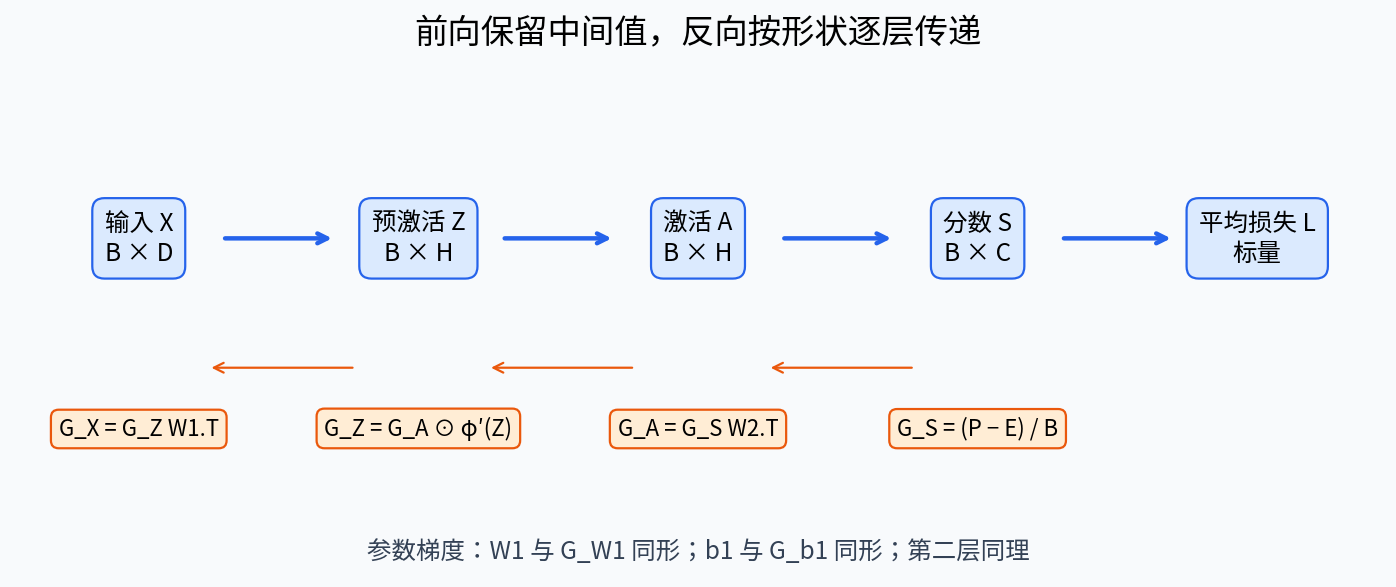

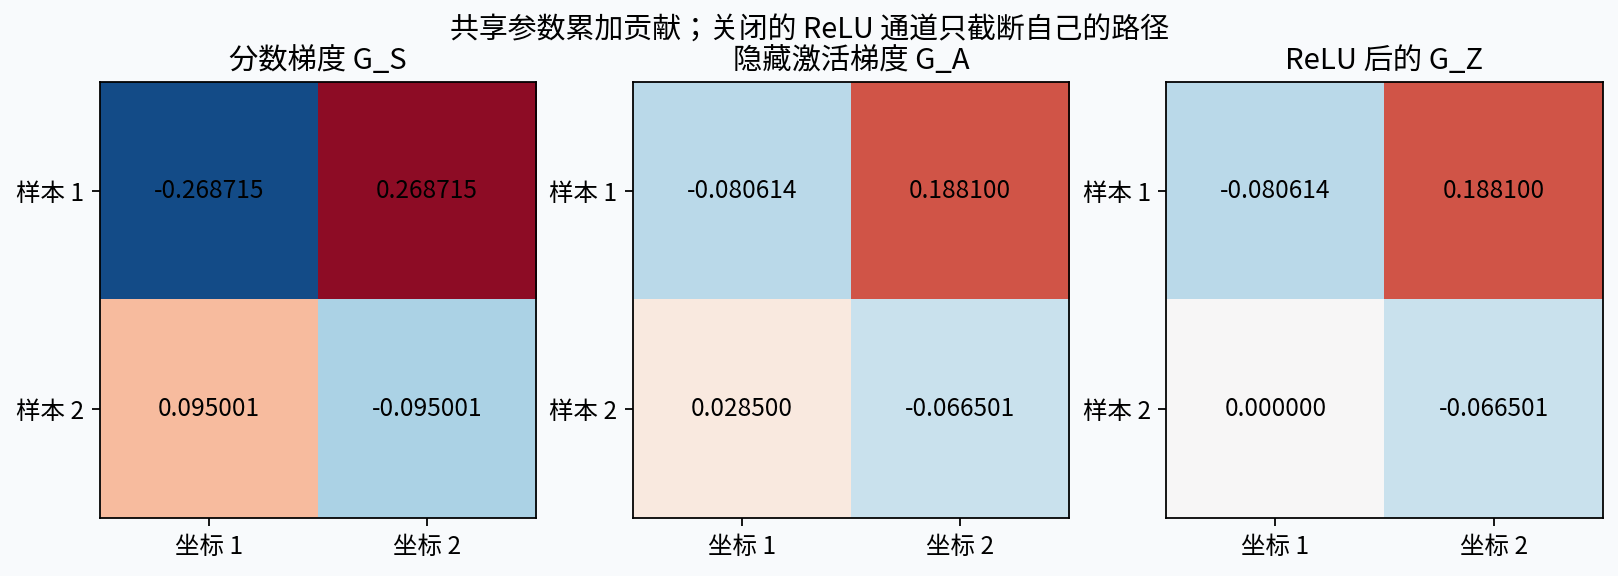

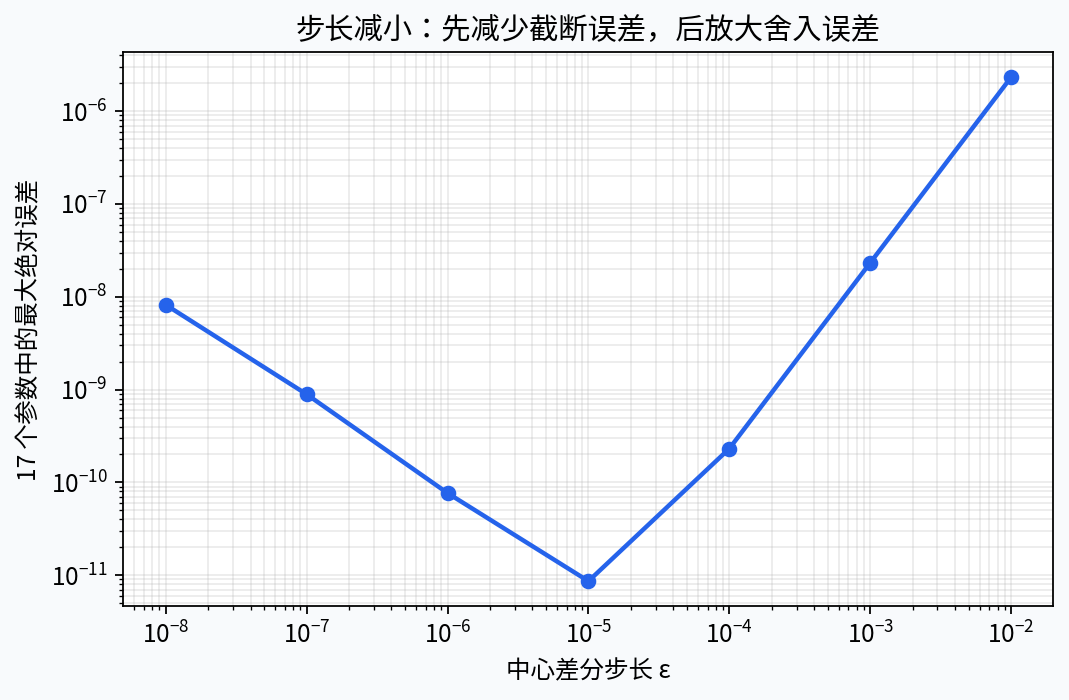

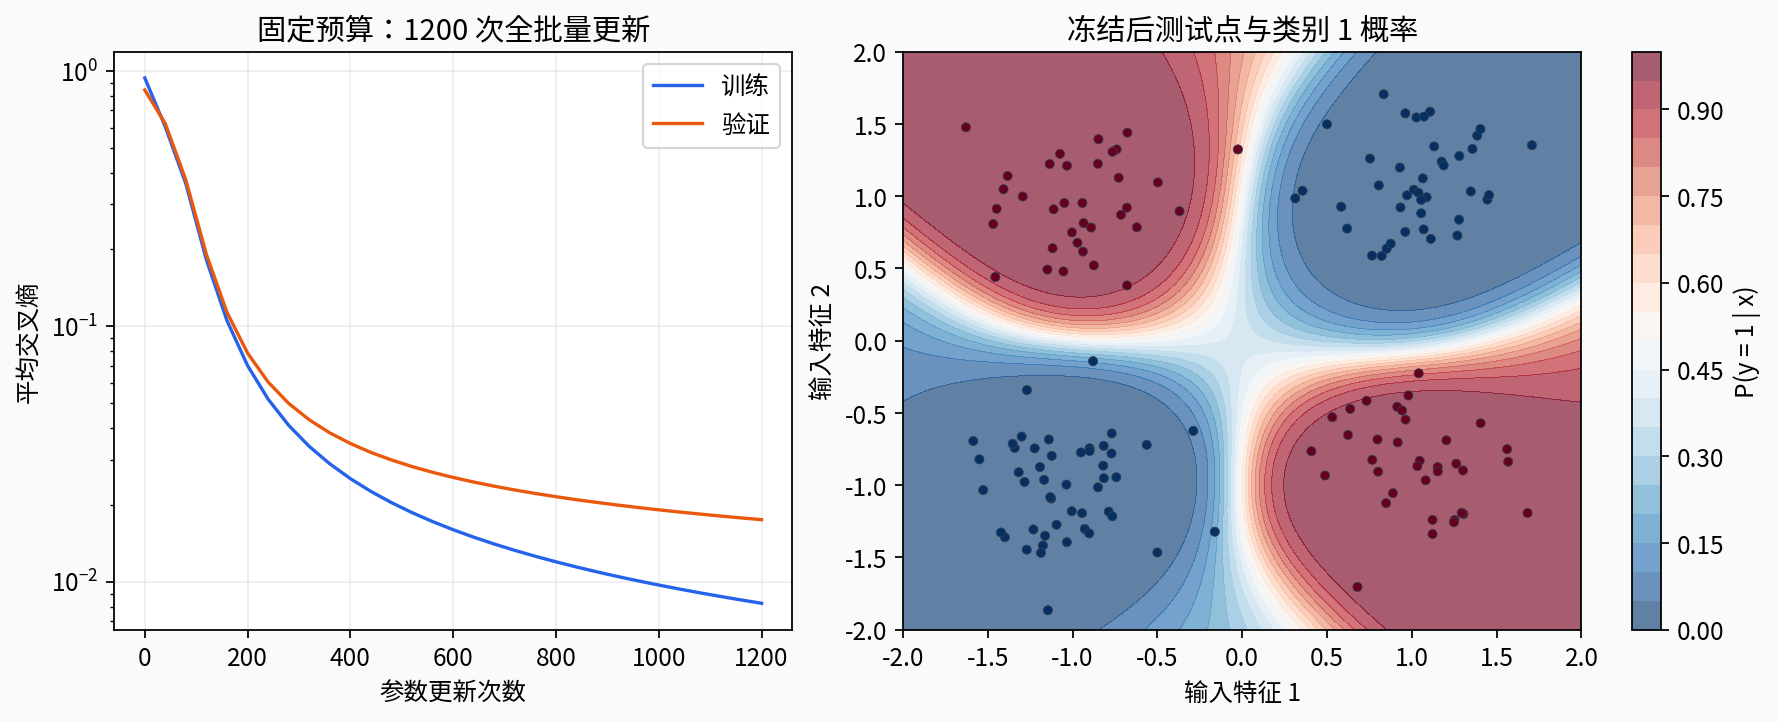

In [8]:
from plots import main as plot_all
from IPython.display import Image, display
paths=plot_all('outputs/notebook-figures','outputs/notebook-result.json')
for path in paths:
    print(Path(path).name)
    display(Image(filename=path))

## 结论边界
数值审计支持实现一致；一次合成训练不能证明现实泛化、校准或全局最优。请回到lab.md完成8题。